# Facial recognition dataset
Before we start training the neural network, let's take a look at the data. 
The goal of this EDA is to understand how many photos we have of each actor and check that the image paths work well.

### 1. Imports
Load the necessary libraries for data manipulation and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import random

# Aesthetic configuration for plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Load Data and Basic Info
Read the CSV file and check its basic structure and data types.

In [2]:
# Load the data
df = pd.read_csv('Dataset.csv')

# Initial inspection of the first rows
display(df.head())

# Check data types and missing values
print("\n--- Dataset Information ---")
df.info()

,id,label
0,Robert Downey Jr_87.jpg,Robert Downey Jr
1,Lisa Kudrow_64.jpg,Lisa Kudrow
2,Ellen Degeneres_34.jpg,Ellen Degeneres
3,Billie Eilish_3.jpg,Billie Eilish
4,Hrithik Roshan_35.jpg,Hrithik Roshan



--- Dataset Information ---
<class 'pandas.DataFrame'>
RangeIndex: 2562 entries, 0 to 2561
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      2562 non-null   str  
 1   label   2562 non-null   str  
dtypes: str(2)
memory usage: 40.2 KB


### 3. Global Statistics
Count the total number of images, unique classes, and check for missing values.

In [3]:
total_images = len(df)
unique_people = df['label'].nunique()

print(f"\nTotal images: {total_images}")
print(f"Unique celebrities (Classes): {unique_people}")

# Check for missing (null) values
print("\nMissing values per column:")
print(df.isnull().sum())


Total images: 2562
Unique celebrities (Classes): 31

Missing values per column:
id       0
label    0
dtype: int64


### 4. Class Imbalance
Visualize how many images belong to each celebrity to identify majority and minority classes.

/tmp/ipykernel_21632/1682083058.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label_counts.index, x=label_counts.values, palette='mako')


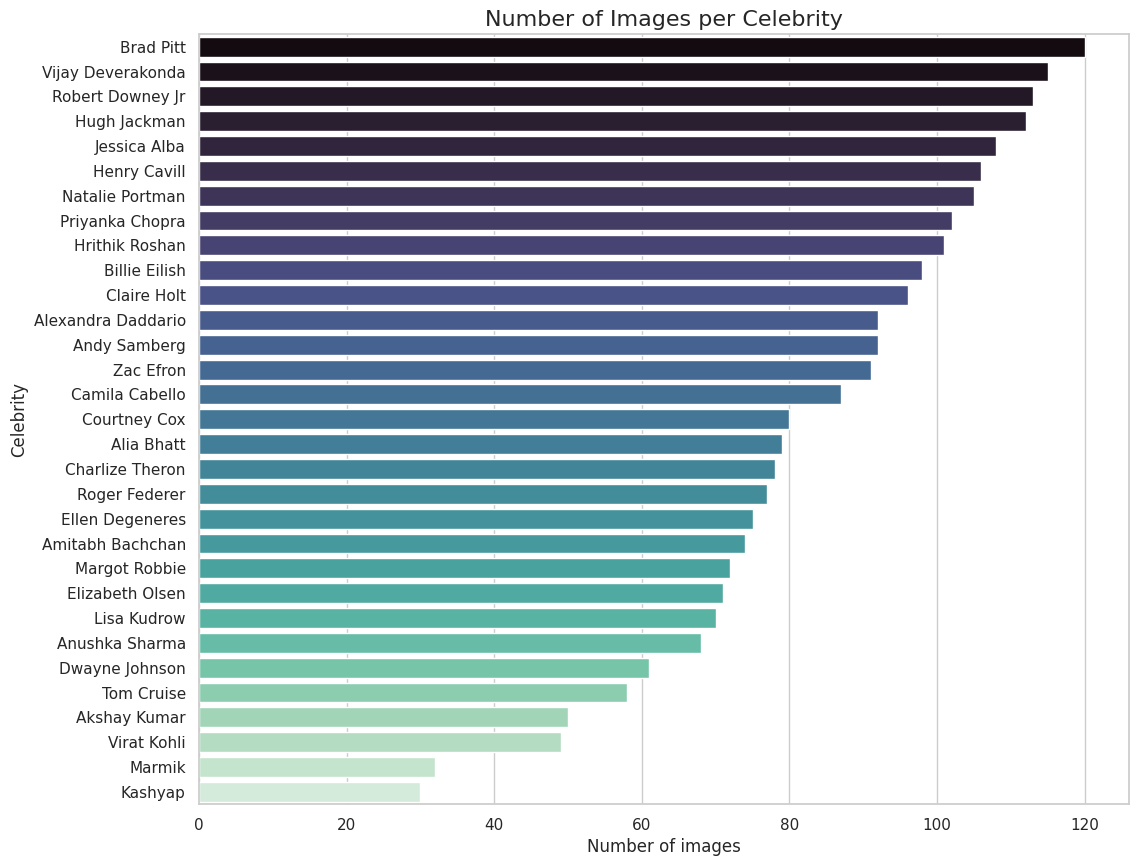

Celebrities with the MOST images:


label
Brad Pitt            120
Vijay Deverakonda    115
Robert Downey Jr     113
Hugh Jackman         112
Jessica Alba         108
Name: count, dtype: int64


Celebrities with the FEWEST images:


label
Tom Cruise      58
Akshay Kumar    50
Virat Kohli     49
Marmik          32
Kashyap         30
Name: count, dtype: int64

In [4]:
# Count the number of images per person
label_counts = df['label'].value_counts()

# Draw the bar plot
plt.figure(figsize=(12, 10))
sns.barplot(y=label_counts.index, x=label_counts.values, palette='mako')
plt.title('Number of Images per Celebrity', fontsize=16)
plt.xlabel('Number of images', fontsize=12)
plt.ylabel('Celebrity', fontsize=12)
plt.show()

# Show the extremes of the list
print("Celebrities with the MOST images:")
display(label_counts.head(5))

print("\nCelebrities with the FEWEST images:")
display(label_counts.tail(5))

### 5. Prepare Image Paths
Create a direct path to the image files based on the folder structure.

In [5]:
# Define the correct path to the images
IMAGE_DIR = './Faces/Faces/' 

# Create a new 'image_path' column by joining the directory and filename
df['image_path'] = df['id'].apply(lambda x: os.path.join(IMAGE_DIR, x))

# Verify it was created successfully
display(df[['id', 'label', 'image_path']].head())

,id,label,image_path
0,Robert Downey Jr_87.jpg,Robert Downey Jr,./Faces/Faces/Robert Downey Jr_87.jpg
1,Lisa Kudrow_64.jpg,Lisa Kudrow,./Faces/Faces/Lisa Kudrow_64.jpg
2,Ellen Degeneres_34.jpg,Ellen Degeneres,./Faces/Faces/Ellen Degeneres_34.jpg
3,Billie Eilish_3.jpg,Billie Eilish,./Faces/Faces/Billie Eilish_3.jpg
4,Hrithik Roshan_35.jpg,Hrithik Roshan,./Faces/Faces/Hrithik Roshan_35.jpg


### 6. Random Visualization
Load and display a random sample of 9 images to verify the data and paths.

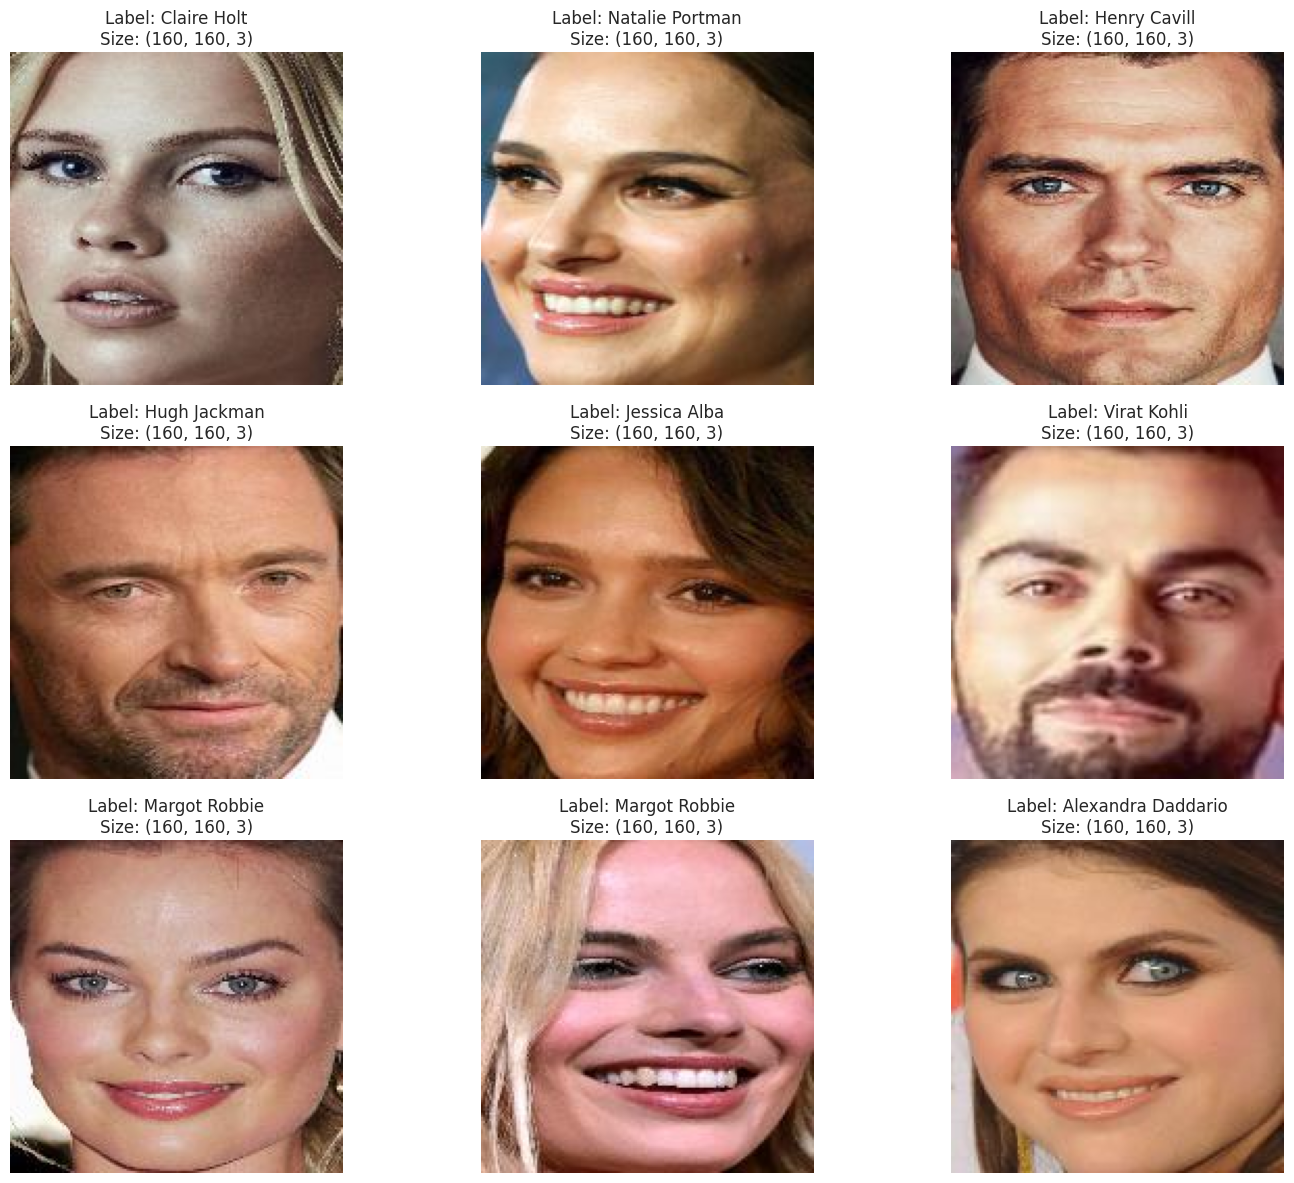

In [6]:
plt.figure(figsize=(15, 12))

# Select 9 random images from the dataframe
sample_df = df.sample(n=9, random_state=42).reset_index(drop=True)

for i in range(9):
    plt.subplot(3, 3, i+1)
    
    # Read the image. OpenCV reads in BGR format
    img_path = sample_df.loc[i, 'image_path']
    img_bgr = cv2.imread(img_path)
    
    if img_bgr is not None:
        # Convert from BGR to RGB for Matplotlib
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        # Display image
        plt.imshow(img_rgb)
        plt.title(f"Label: {sample_df.loc[i, 'label']}\nSize: {img_rgb.shape}", fontsize=12)
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, 'Image not found', ha='center', va='center', fontsize=12)
        plt.axis('off')

plt.tight_layout()
plt.show()

### 7. Image Resolution and Aspect Ratio Analysis
In this section, we will scan through all the images in the dataset to extract their dimensions (width and height). This will help us understand if the images are uniform or if we need to apply specific cropping/padding strategies before resizing them for the neural network.

In [7]:
!pip install tqdm

Scanning image dimensions...


100%|██████████████████████████████████████████████████████████████████████████████| 2562/2562 [00:22<00:00, 111.69it/s]


All images loaded successfully!


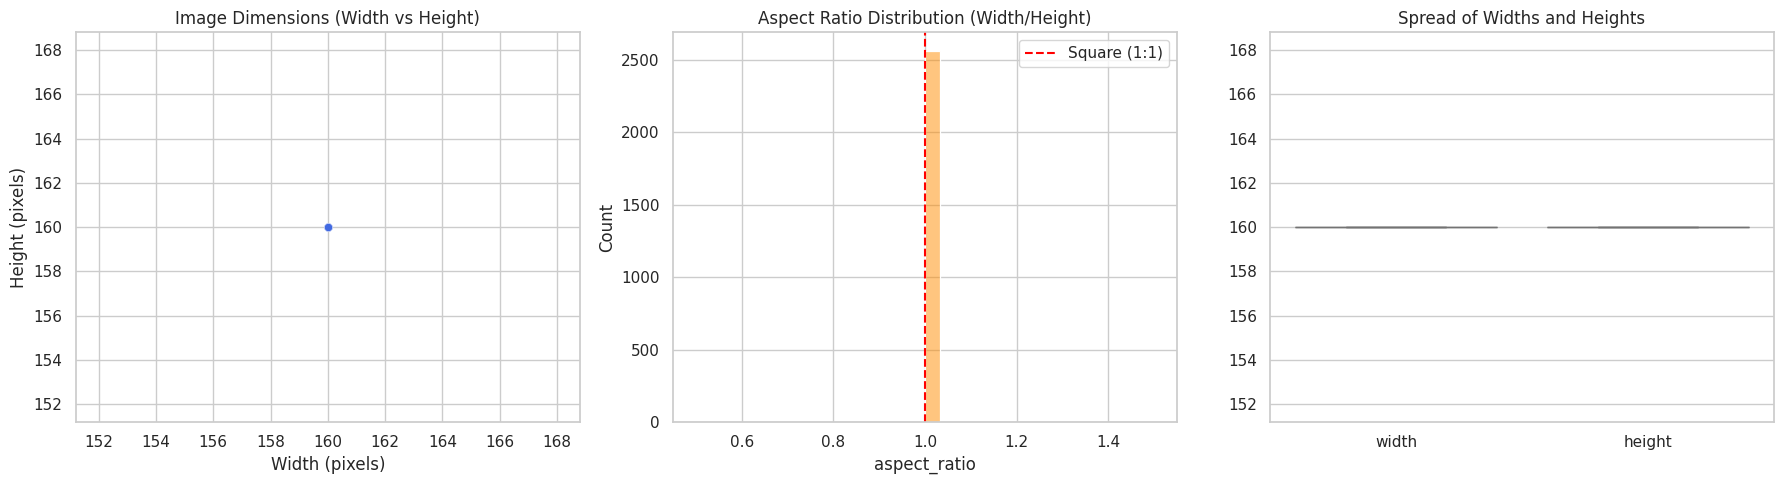

Average Width: 160 px
Average Height: 160 px


In [8]:
from tqdm import tqdm
import cv2

# Lists to store dimensions
widths = []
heights = []
broken_images = []

print("Scanning image dimensions...")
# tqdm adds a nice progress bar
for path in tqdm(df['image_path']):
    img = cv2.imread(path)
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)
    else:
        broken_images.append(path)

# Add dimensions to our dataframe (excluding broken images if any)
# For simplicity, if there are broken images, we just print them.
if len(broken_images) > 0:
    print(f"Warning: Found {len(broken_images)} unreadable images!")
else:
    print("All images loaded successfully!")
    df['width'] = widths
    df['height'] = heights
    df['aspect_ratio'] = df['width'] / df['height']

    # Visualizing the distribution of dimensions
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot 1: Width vs Height Scatter
    sns.scatterplot(x='width', y='height', data=df, alpha=0.5, ax=axes[0], color='royalblue')
    axes[0].set_title('Image Dimensions (Width vs Height)')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Height (pixels)')

    # Plot 2: Aspect Ratio Histogram
    sns.histplot(df['aspect_ratio'], bins=30, kde=True, ax=axes[1], color='darkorange')
    axes[1].set_title('Aspect Ratio Distribution (Width/Height)')
    axes[1].axvline(1.0, color='red', linestyle='--', label='Square (1:1)')
    axes[1].legend()

    # Plot 3: Boxplot of dimensions
    sns.boxplot(data=df[['width', 'height']], ax=axes[2], palette='pastel')
    axes[2].set_title('Spread of Widths and Heights')

    plt.tight_layout()
    plt.show()

    print(f"Average Width: {df['width'].mean():.0f} px")
    print(f"Average Height: {df['height'].mean():.0f} px")

### 10. Brightness Analysis
In real-world scenarios, images come from various sources with different lighting conditions. If a specific celebrity only has dark photos (e.g., from a dark movie scene), the neural network might learn to associate "darkness" with that person instead of their facial features. 

Here we calculate the average brightness of each image to check the lighting distribution of our dataset. This analysis justifies our use of `ColorJitter` during the Data Augmentation phase.

Calculating average brightness for each image...


100%|██████████████████████████████████████████████████████████████████████████████| 2562/2562 [00:16<00:00, 153.14it/s]


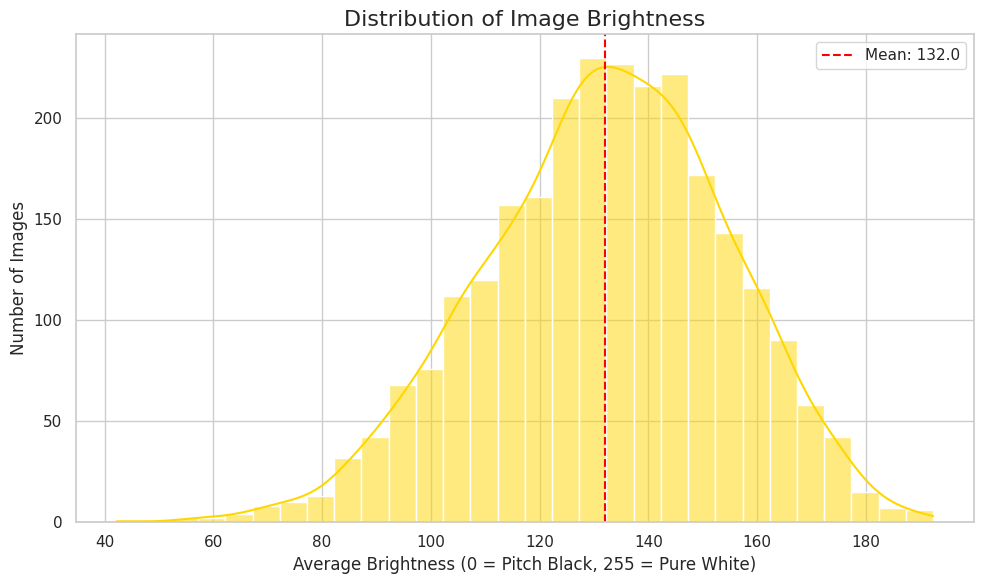

In [9]:
from tqdm import tqdm
import cv2

print("Calculating average brightness for each image...")
brightness_values = []

# Scan all images to calculate their mean pixel intensity
for path in tqdm(df['image_path']):
    img = cv2.imread(path)
    if img is not None:
        # Convert to Grayscale (0 = black, 255 = white)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        brightness_values.append(gray.mean())
    else:
        brightness_values.append(None) # For broken images

# Add to dataframe and drop any broken ones
df['brightness'] = brightness_values
df_clean = df.dropna(subset=['brightness'])

# Plotting the brightness distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['brightness'], bins=30, kde=True, color='gold')

plt.title('Distribution of Image Brightness', fontsize=16)
plt.xlabel('Average Brightness (0 = Pitch Black, 255 = Pure White)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add vertical lines for visual reference
plt.axvline(df_clean['brightness'].mean(), color='red', linestyle='--', label=f"Mean: {df_clean['brightness'].mean():.1f}")
plt.legend()

plt.tight_layout()
plt.show()

### 11. EDA Conclusions & Next Steps
Based on our Exploratory Data Analysis, we have identified several key aspects of our dataset:
1. **Class Imbalance:** Some celebrities have around 120 images while others have only 30. We will handle this using Data Augmentation for minority classes.
2. **Varying Lighting:** The brightness analysis shows varying lighting conditions, making `ColorJitter` a necessary preprocessing step.
3. **Future Improvement (Face Cropping):** Currently, some images might contain full bodies or extensive backgrounds. A potential future improvement to increase model accuracy would be to use a Face Detection algorithm (like MTCNN or Haar Cascades) to automatically crop the images tightly around the faces before feeding them to the ResNet model.

### 7. Label Encoding & Data Splitting
Before feeding data into a neural network, we need to convert text labels (celebrity names) into numeric indices. Then, we will split our dataset into Training (70%), Validation (15%), and Testing (15%) sets, ensuring the class distribution is maintained (`stratify`).

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("--- LABEL ENCODING ---")
# Convert actor names to numeric indices (0 to 30)
le = LabelEncoder()
df['label_idx'] = le.fit_transform(df['label'])

# Create a dictionary to map indices back to names later
idx_to_class = dict(zip(le.transform(le.classes_), le.classes_))
num_classes = len(le.classes_)
print(f"Successfully encoded {num_classes} classes.")

print("\n--- DATA SPLIT (70% Train, 15% Val, 15% Test) ---")
# First, split into Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df['label_idx']
)

# Next, split Temp into Val (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df['label_idx']
)

# Reset indices to avoid issues later
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Test images: {len(test_df)}")

--- LABEL ENCODING ---
Successfully encoded 31 classes.

--- DATA SPLIT (70% Train, 15% Val, 15% Test) ---
Training images: 1793
Validation images: 384
Test images: 385


### 8. Data Augmentation & Custom Dataset
To help the model generalize better and avoid memorizing the training images (especially for classes with fewer photos), we apply data augmentation (flips, rotations, color jitter). We also define a custom PyTorch `Dataset` to load the images dynamically.

In [31]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import random

class SiameseFacesDataset(Dataset):
    def __init__(self, df, transform=None):
        # Fem un reset_index per assegurar-nos que els índexs van de 0 a N
        self.df = df.reset_index(drop=True) 
        self.transform = transform
        self.labels = self.df['label'].unique()
        
        # Agrupem els índexs de les imatges per cada celebritat per facilitar el mostreig
        self.label_to_indices = {label: self.df[self.df['label'] == label].index.tolist() for label in self.labels}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # 1. Seleccionem la primera imatge i la carreguem
        img1_path = self.df.loc[idx, 'image_path']
        label1 = self.df.loc[idx, 'label']
        img1 = Image.open(img1_path).convert('RGB')

        # 2. Decidim aleatòriament si volem una parella de la mateixa persona (1) o diferent (0)
        target = random.randint(0, 1)

        if target == 1:
            # Parem la mateixa persona (Match)
            idx2 = random.choice(self.label_to_indices[label1])
            img2_path = self.df.loc[idx2, 'image_path']
        else:
            # Parem una persona diferent (Different)
            different_label = random.choice([l for l in self.labels if l != label1])
            idx2 = random.choice(self.label_to_indices[different_label])
            img2_path = self.df.loc[idx2, 'image_path']

        # Carreguem la segona imatge
        img2 = Image.open(img2_path).convert('RGB')

        # 3. Apliquem les transformacions (Data Augmentation o ToTensor)
        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        # Retornem les dues imatges i l'etiqueta com a tensor de tipus float
        return img1, img2, torch.tensor(target, dtype=torch.float32)

### 9. DataLoaders
Finally, we wrap our Datasets in `DataLoaders`. These will efficiently feed batches of images to the GPU (or CPU) during the training loop.

In [32]:
BATCH_SIZE = 32

# Instantiate the Siamese datasets
siamese_train_dataset = SiameseFacesDataset(train_df, transform=train_transforms)
siamese_val_dataset = SiameseFacesDataset(val_df, transform=test_transforms)
siamese_test_dataset = SiameseFacesDataset(test_df, transform=test_transforms)

# Create DataLoaders
train_loader = DataLoader(siamese_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(siamese_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(siamese_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Check the shape of a single batch
img1_batch, img2_batch, targets_batch = next(iter(train_loader))
print(f"Image 1 batch shape: {img1_batch.shape}")
print(f"Image 2 batch shape: {img2_batch.shape}")
print(f"Targets batch shape: {targets_batch.shape} (1 = Match, 0 = Different)")

Image 1 batch shape: torch.Size([32, 3, 224, 224])
Image 2 batch shape: torch.Size([32, 3, 224, 224])
Targets batch shape: torch.Size([32]) (1 = Match, 0 = Different)


## Phase 2: Model Building & Training
Now that our data is ready, we will define our model architecture. We will use Transfer Learning with a pre-trained ResNet18 model. 

1. Architecture: ResNet18 (pre-trained on ImageNet).
2. Modification: Replace the final layer (1000 classes) with a new one for our 31 celebrities.
3. Training Strategy: Initially, we will freeze the early layers and only train the "head" to speed up convergence.

In [33]:
import torch
import torch.nn as nn
import torchvision.models as models

# 1. Definim el dispositiu (GPU si n'hi ha, si no CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Definim la classe de la Xarxa Siamesa
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        # Carreguem ResNet18 pre-entrenat
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Eliminem l'última capa de classificació per obtenir només els vectors de característiques (embeddings)
        self.resnet.fc = nn.Identity()

    def forward_once(self, x):
        return self.resnet(x)

    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

# 3. Creem el model i el movem al device
model = SiameseNetwork().to(device)
print(f"Model Siamès creat i mogut a: {device}")

Model Siamès creat i mogut a: cpu


### Define Loss Function and Optimizer
We use **CrossEntropyLoss** for multiclass classification and the **Adam** optimizer, which is generally faster than standard SGD.

In [34]:
import torch.optim as optim
import torch.nn.functional as F

# 1. Definim la Contrastive Loss (Estàndard per xarxes siameses)
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=2.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # label = 1 (mateixa persona), label = 0 (diferent)
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=True)
        # Ajustem les dimensions per evitar errors
        label = label.view(-1, 1) 
        
        loss_contrastive = torch.mean((label) * torch.pow(euclidean_distance, 2) +
                                      (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive

criterion = ContrastiveLoss()

# 2. Definim l'optimitzador apuntant al model correcte
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function (ContrastiveLoss) and Optimizer defined.")

Loss function (ContrastiveLoss) and Optimizer defined.


### Training Loop
This function will handle the training and validation for each epoch, keeping track of the loss and accuracy to monitor performance.

In [37]:
import time

def train_siamese_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    start_time = time.time()
    
    # Per guardar l'historial
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        
        # AQUÍ ESTÀ EL CANVI! Ara desempaquetem 3 variables
        for img1, img2, labels in train_loader:
            # Movem les 3 coses al device (CPU o GPU)
            img1 = img1.to(device)
            img2 = img2.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Passem les dues imatges per la xarxa siamesa
            # El model siamès acostuma a retornar dos outputs
            output1, output2 = model(img1, img2)
            
            # Calculem la pèrdua passant els dos outputs i la etiqueta
            loss = criterion(output1, output2, labels)
            
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * img1.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history['train_loss'].append(epoch_loss)

        # Bucle de Validació
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for img1, img2, labels in val_loader:
                img1 = img1.to(device)
                img2 = img2.to(device)
                labels = labels.to(device)

                output1, output2 = model(img1, img2)
                loss = criterion(output1, output2, labels)
                
                val_loss += loss.item() * img1.size(0)

        epoch_val_loss = val_loss / len(val_loader.dataset)
        history['val_loss'].append(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Val Loss: {epoch_val_loss:.4f}")
        
    time_elapsed = time.time() - start_time
    print(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    
    return history

In [ ]:
NUM_EPOCHS = 10

print("Starting Siamese ResNet18 model Training...")
history = train_siamese_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=NUM_EPOCHS)

Starting Siamese ResNet18 model Training...


In [41]:
# Plot the training evolution (Only the loss for now)
plt.figure(figsize=(8, 5))
plt.plot(range(1, NUM_EPOCHS+1), history['train_loss'], label='Training Loss', color='crimson', marker='o', linewidth=2)
plt.plot(range(1, NUM_EPOCHS+1), history['val_loss'], label='Validation Loss', color='royalblue', marker='s', linewidth=2)
plt.title('Loss Evolution (Contrastive Loss)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'history' is not defined

<Figure size 800x500 with 0 Axes>